# Overload Penalty

The oracle penalizes users whose **total plant `difficulty_score`** exceeds a care-level threshold:

```
OVERLOAD_THRESHOLDS = {"easy": 100, "medium": 200, "hard": 400}
OVERLOAD_PENALTY_MAX = 0.18

excess = max(0, total_difficulty - threshold)
overload = excess / 100
overload_penalty = 1 - 1 / (1 + 0.20 * overload)
survival_prob -= overload_penalty * 0.18
```

A beginner (easy) gets overwhelmed at 100 total difficulty, an expert (hard) at 400.

**Hypothesis:** Users with more excess difficulty should have lower survival rates and model scores. Since almost all easy/medium users are overloaded, we bucket by **excess amount** within each care level to show the gradual penalty curve.

## 1. Setup & Load Data

In [9]:
import json
import sys
from collections import defaultdict
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "resources").exists():
    for c in [ROOT.parent, ROOT.parent.parent, ROOT.parent.parent.parent]:
        if (c / "resources").exists():
            ROOT = c
            break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

INTERACTIONS_PATH = ROOT / "resources" / "data" / "synthetic_interactions.json"
USERS_PATH = ROOT / "resources" / "data" / "synthetic_users.json"
PLANTS_PATH = ROOT / "resources" / "data_creating" / "permapeople_plants_mapped_normalized.json"
PLANTS_ALT = ROOT / "resources" / "data_creating" / "permapeople_plants_mapped_uniform.json"
OUTPUT_DIR = ROOT / "resources" / "verify" / "overload penalty"

OVERLOAD_THRESHOLDS = {"easy": 100, "medium": 200, "hard": 400}

## 2. Load Data

In [10]:
def load_data():
    with open(INTERACTIONS_PATH) as f:
        interactions = json.load(f)
    with open(USERS_PATH) as f:
        users = json.load(f)
    path = PLANTS_PATH if PLANTS_PATH.exists() else PLANTS_ALT
    with open(path) as f:
        plants = json.load(f).get("plants", [])
    user_by_id = {u["user_id"]: u for u in users}
    plant_by_id = {p.get("id"): p for p in plants if p.get("id") is not None}
    return interactions, user_by_id, plant_by_id

interactions, user_by_id, plant_by_id = load_data()
print(f"{len(interactions)} interactions, {len(user_by_id)} users, {len(plant_by_id)} plants")

11206 interactions, 810 users, 1000 plants


## 3. Compute Per-User Total Difficulty & Excess Brackets

In [11]:
def _norm(val):
    if val is None:
        return None
    return str(val).strip().lower() or None


user_total_difficulty = defaultdict(float)
for r in interactions:
    plant = plant_by_id.get(r["plant_id"])
    diff = float(plant.get("difficulty_score") or 0) if plant else 0
    user_total_difficulty[r["user_id"]] += diff


EXCESS_BINS = ["0", "1-100", "101-200", "201-300", "300+"]

def excess_bracket(excess: float) -> str:
    if excess <= 0:
        return "0"
    elif excess <= 100:
        return "1-100"
    elif excess <= 200:
        return "101-200"
    elif excess <= 300:
        return "201-300"
    else:
        return "300+"

def get_user_excess(user_id):
    """Return (care_level, excess, bracket) for a user."""
    user = user_by_id.get(user_id, {})
    care_level = _norm(user.get("care_level")) or "medium"
    threshold = OVERLOAD_THRESHOLDS.get(care_level, 200)
    total_diff = user_total_difficulty.get(user_id, 0)
    excess = max(0.0, total_diff - threshold)
    return care_level, excess, excess_bracket(excess)

# Quick summary: how many users per care level fall in each excess bracket
from collections import Counter
bracket_counts = defaultdict(Counter)
for uid in user_by_id:
    care, _, bracket = get_user_excess(uid)
    bracket_counts[care][bracket] += 1

for care in ["easy", "medium", "hard"]:
    print(f"--- {care} (threshold={OVERLOAD_THRESHOLDS[care]}) ---")
    for b in EXCESS_BINS:
        print(f"  excess {b:8s}: {bracket_counts[care].get(b, 0)} users")

--- easy (threshold=100) ---
  excess 0       : 0 users
  excess 1-100   : 0 users
  excess 101-200 : 26 users
  excess 201-300 : 56 users
  excess 300+    : 310 users
--- medium (threshold=200) ---
  excess 0       : 0 users
  excess 1-100   : 0 users
  excess 101-200 : 0 users
  excess 201-300 : 9 users
  excess 300+    : 60 users
--- hard (threshold=400) ---
  excess 0       : 117 users
  excess 1-100   : 57 users
  excess 101-200 : 63 users
  excess 201-300 : 9 users
  excess 300+    : 103 users


## 4. Survival by Care Level × Excess Bracket

In [12]:
def survival_by_care_excess(interactions):
    """Group interactions by (care_level, excess_bracket) and compute survival."""
    groups = defaultdict(list)
    for r in interactions:
        care, _, bracket = get_user_excess(r["user_id"])
        groups[(care, bracket)].append(r.get("label", 0))

    stats = {}
    for key, labels in groups.items():
        n = len(labels)
        stats[key] = {"n": n, "survival_rate": sum(labels) / n if n else 0}
    return stats

surv_stats = survival_by_care_excess(interactions)

for care in ["easy", "medium", "hard"]:
    print(f"--- {care} ---")
    for b in EXCESS_BINS:
        s = surv_stats.get((care, b), {})
        print(f"  excess {b:8s}: survival={s.get('survival_rate', 0):.3f}  n={s.get('n', 0)}")

--- easy ---
  excess 0       : survival=0.000  n=0
  excess 1-100   : survival=0.000  n=0
  excess 101-200 : survival=0.830  n=159
  excess 201-300 : survival=0.845  n=445
  excess 300+    : survival=0.544  n=4966
--- medium ---
  excess 0       : survival=0.000  n=0
  excess 1-100   : survival=0.000  n=0
  excess 101-200 : survival=0.000  n=0
  excess 201-300 : survival=0.736  n=91
  excess 300+    : survival=0.656  n=1088
--- hard ---
  excess 0       : survival=0.877  n=729
  excess 1-100   : survival=0.816  n=553
  excess 101-200 : survival=0.812  n=750
  excess 201-300 : survival=0.516  n=122
  excess 300+    : survival=0.700  n=2303


## 5. Plot: Survival by Care Level × Excess Bracket

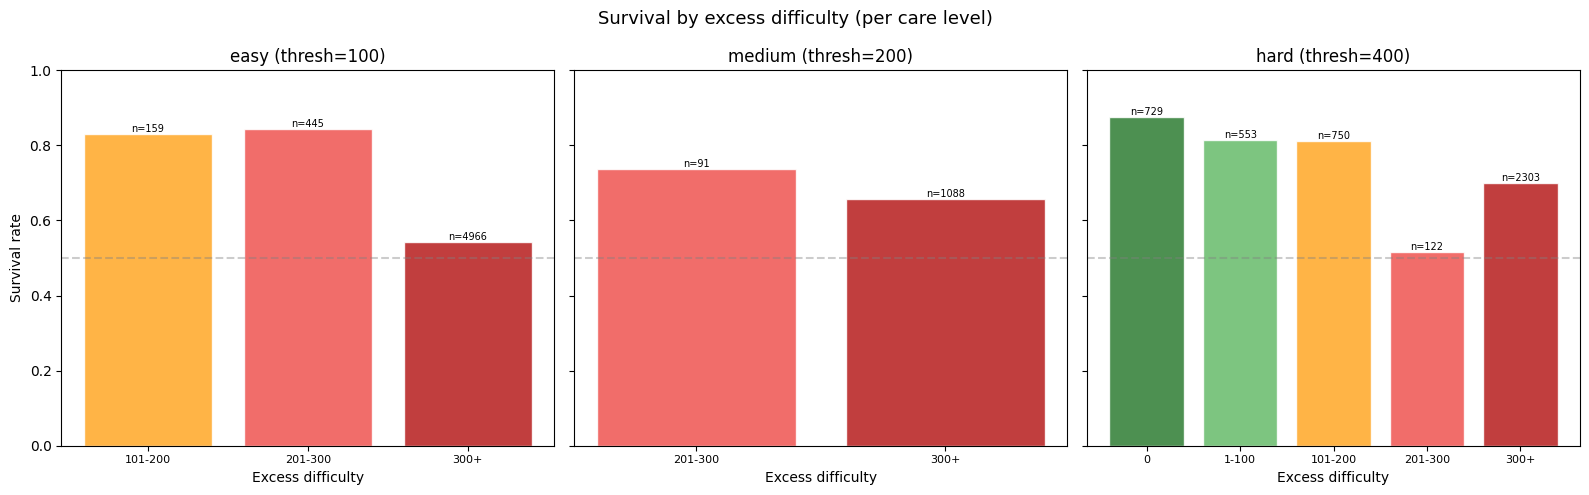

In [13]:
import matplotlib.pyplot as plt
import numpy as np

care_levels = ["easy", "medium", "hard"]
colors = ["#2e7d32", "#66bb6a", "#ffa726", "#ef5350", "#b71c1c"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor="white", sharey=True)

for idx, care in enumerate(care_levels):
    ax = axes[idx]
    bins_present = [b for b in EXCESS_BINS if surv_stats.get((care, b), {}).get("n", 0) > 0]
    vals = [surv_stats[(care, b)]["survival_rate"] for b in bins_present]
    counts = [surv_stats[(care, b)]["n"] for b in bins_present]
    bar_colors = [colors[EXCESS_BINS.index(b)] for b in bins_present]
    x = np.arange(len(bins_present))

    bars = ax.bar(x, vals, color=bar_colors, alpha=0.85, edgecolor="white")
    for bar, n in zip(bars, counts):
        ax.annotate(f"n={n}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(bins_present, fontsize=8)
    ax.set_xlabel("Excess difficulty")
    ax.set_title(f"{care} (thresh={OVERLOAD_THRESHOLDS[care]})")
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4)

axes[0].set_ylabel("Survival rate")
fig.suptitle("Survival by excess difficulty (per care level)", fontsize=13)

plt.tight_layout()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_DIR / "overload_survival.png", dpi=120, bbox_inches="tight", facecolor="white")
plt.show()

## 6. Model: Does It Learn the Overload Penalty?

Load the two-tower model and compute mean model score per (care_level, overload) group.

In [14]:
import torch
from resources.ETL.feature_engineer import apply_user_embeddings, apply_categorical_embeddings

users_list = list(user_by_id.values())
plants_list = list(plant_by_id.values())
apply_user_embeddings(users_list)
apply_categorical_embeddings(plants_list)
user_by_id = {u["user_id"]: u for u in users_list}
plant_by_id = {p.get("id"): p for p in plants_list}

model = None
for p in [ROOT / "resources" / "two_tower_training" / "two_tower.pt",
          ROOT / "resources" / "two_tower_training" / "output" / "two_tower.pt"]:
    if p.exists():
        ckpt = torch.load(p, map_location="cpu", weights_only=True)
        state = ckpt.get("model_state", ckpt)
        if any("user_tower.mlp" in k for k in state.keys()):
            from resources.two_tower_training.two_tower_model import TwoTowerModel
            model = TwoTowerModel()
            model.load_state_dict(state, strict=True)
            model.eval()
            print(f"Loaded model from {p}")
            break
if model is None:
    print("Model not found — skip model analysis.")

Loaded model from /Users/yemarnaung/Documents/Projects/HowToKeepYourPlantsAlive/resources/two_tower_training/output/two_tower.pt


In [15]:
def model_scores_by_care_excess(interactions, user_by_id, plant_by_id, model):
    """Compute mean model score per (care_level, excess_bracket) group."""
    batch_u, batch_p, batch_keys = [], [], []
    for r in interactions:
        u = user_by_id.get(r["user_id"], {})
        p = plant_by_id.get(r["plant_id"]) or {}
        if not p or "categorical_embedding" not in p:
            continue
        u_emb = u.get("categorical_embedding")
        if not u_emb or len(u_emb) != 21:
            continue
        care, _, bracket = get_user_excess(r["user_id"])
        batch_u.append(list(u_emb) + [0.0] * 64 + [0.0] * 64)
        batch_p.append(p["categorical_embedding"])
        batch_keys.append((care, bracket))

    if not batch_u:
        return None
    u_t = torch.tensor(batch_u, dtype=torch.float32)
    p_t = torch.tensor(batch_p, dtype=torch.float32)
    with torch.no_grad():
        scores = model(u_t, p_t).numpy()

    by_group = defaultdict(list)
    for key, sc in zip(batch_keys, scores):
        by_group[key].append(float(sc))

    return {k: {"n": len(v), "mean_score": sum(v) / len(v)} for k, v in by_group.items()}

if model:
    model_stats = model_scores_by_care_excess(interactions, user_by_id, plant_by_id, model)
    if model_stats:
        for care in ["easy", "medium", "hard"]:
            print(f"--- {care} ---")
            for b in EXCESS_BINS:
                s = model_stats.get((care, b), {})
                print(f"  excess {b:8s}: model_score={s.get('mean_score', 0):.4f}  n={s.get('n', 0)}")
else:
    model_stats = None
    print("Model not loaded — skip.")

--- easy ---
  excess 0       : model_score=0.0000  n=0
  excess 1-100   : model_score=0.0000  n=0
  excess 101-200 : model_score=4.0138  n=159
  excess 201-300 : model_score=4.1834  n=445
  excess 300+    : model_score=3.8413  n=4966
--- medium ---
  excess 0       : model_score=0.0000  n=0
  excess 1-100   : model_score=0.0000  n=0
  excess 101-200 : model_score=0.0000  n=0
  excess 201-300 : model_score=6.0994  n=91
  excess 300+    : model_score=6.0950  n=1088
--- hard ---
  excess 0       : model_score=6.1515  n=729
  excess 1-100   : model_score=6.0979  n=553
  excess 101-200 : model_score=6.1909  n=750
  excess 201-300 : model_score=6.1174  n=122
  excess 300+    : model_score=6.1223  n=2303


## 7. Plot: Survival + Model Score by Excess Bracket (Dual Y-Axis)

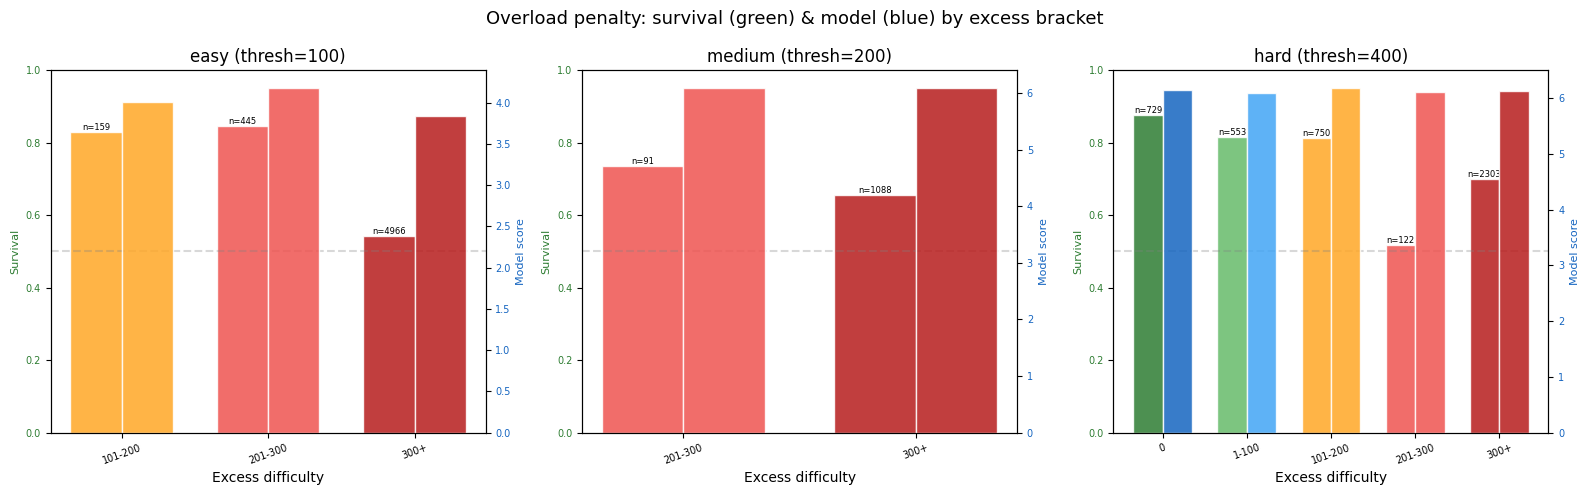

In [16]:
if model_stats:
    care_levels = ["easy", "medium", "hard"]
    surv_colors = ["#2e7d32", "#66bb6a", "#ffa726", "#ef5350", "#b71c1c"]
    model_colors = ["#1565c0", "#42a5f5", "#ffa726", "#ef5350", "#b71c1c"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor="white")

    for idx, care in enumerate(care_levels):
        ax = axes[idx]
        ax_twin = ax.twinx()

        bins_present = [b for b in EXCESS_BINS
                        if surv_stats.get((care, b), {}).get("n", 0) > 0
                        or model_stats.get((care, b), {}).get("n", 0) > 0]
        x = np.arange(len(bins_present))
        w = 0.35

        s_vals = [surv_stats.get((care, b), {}).get("survival_rate", 0) for b in bins_present]
        m_vals = [model_stats.get((care, b), {}).get("mean_score", 0) for b in bins_present]
        s_n = [surv_stats.get((care, b), {}).get("n", 0) for b in bins_present]
        s_colors = [surv_colors[EXCESS_BINS.index(b)] for b in bins_present]
        m_colors = [model_colors[EXCESS_BINS.index(b)] for b in bins_present]

        bars_s = ax.bar(x - w / 2, s_vals, w, color=s_colors, alpha=0.85, edgecolor="white")
        bars_m = ax_twin.bar(x + w / 2, m_vals, w, color=m_colors, alpha=0.85, edgecolor="white")

        for bar, n in zip(bars_s, s_n):
            ax.annotate(f"n={n}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                        ha="center", va="bottom", fontsize=6)

        ax.set_xticks(x)
        ax.set_xticklabels(bins_present, fontsize=7, rotation=20)
        ax.set_xlabel("Excess difficulty")
        ax.set_title(f"{care} (thresh={OVERLOAD_THRESHOLDS[care]})")
        ax.set_ylim(0, 1)
        ax.axhline(0.5, color="gray", linestyle="--", alpha=0.3)

        ax.set_ylabel("Survival", color="#2e7d32", fontsize=8)
        ax_twin.set_ylabel("Model score", color="#1565c0", fontsize=8)
        ax.tick_params(axis="y", labelcolor="#2e7d32", labelsize=7)
        ax_twin.tick_params(axis="y", labelcolor="#1565c0", labelsize=7)

    fig.suptitle("Overload penalty: survival (green) & model (blue) by excess bracket", fontsize=13)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "overload_model.png", dpi=120, bbox_inches="tight", facecolor="white")
    plt.show()
else:
    print("Model not loaded — combined plot skipped.")

## 8. Summary

- **Oracle:** When a user's total `difficulty_score` exceeds their care-level threshold (`easy=100`, `medium=200`, `hard=400`), all their plants receive a gradual survival penalty up to `0.18`.
- **Excess brackets:** Because nearly all easy/medium users are overloaded, we bucket by **excess amount** (`0`, `1-100`, `101-200`, `201-300`, `300+`) within each care level. This reveals the *gradual* nature of the penalty (`1 - 1/(1 + 0.20 * excess/100)`).
- **Expected pattern:** Higher excess → lower survival, and ideally lower model scores.
- **User-level signal:** This penalty depends on the user's entire plant portfolio, not individual plant features. The model can only learn this from aggregate features in the user embedding.